# The SNN Transmitter ("Real" Neural Source, the "Bat Neuron")

This is a fundamental change to Cell 1. We are removing the random numpy spike generator and replacing it with an snntorch Leaky Integrate-and-Fire (LIF) neuron. We feed this neuron a constant "drive" current. Its natural membrane dynamics (leaking, integrating, firing, and resetting) will produce a semi-regular, biologically plausible spike train.

This new spike train is governed by the neuron's time constant (beta), not just random chance. Cells 2 and 3 are the standard 1D physics and analysis sections, used here to verify that our system still works perfectly with this new, authentic spike source.

### Cell 1: The SNN Transmitter

Concept: Using an LIF neuron to generate the source spike train.

Here, we import torch and snntorch. We create a single snn.Leaky neuron and run a simulation loop, feeding it a constant input_current at every time step. The neuron's voltage rises, hits the threshold, fires, and resets. The resulting sent_spikes are then converted to a numpy array and used to build the radar signal just as before.

Running SNN Transmitter simulation...
SNN neuron fired 0.0 times.


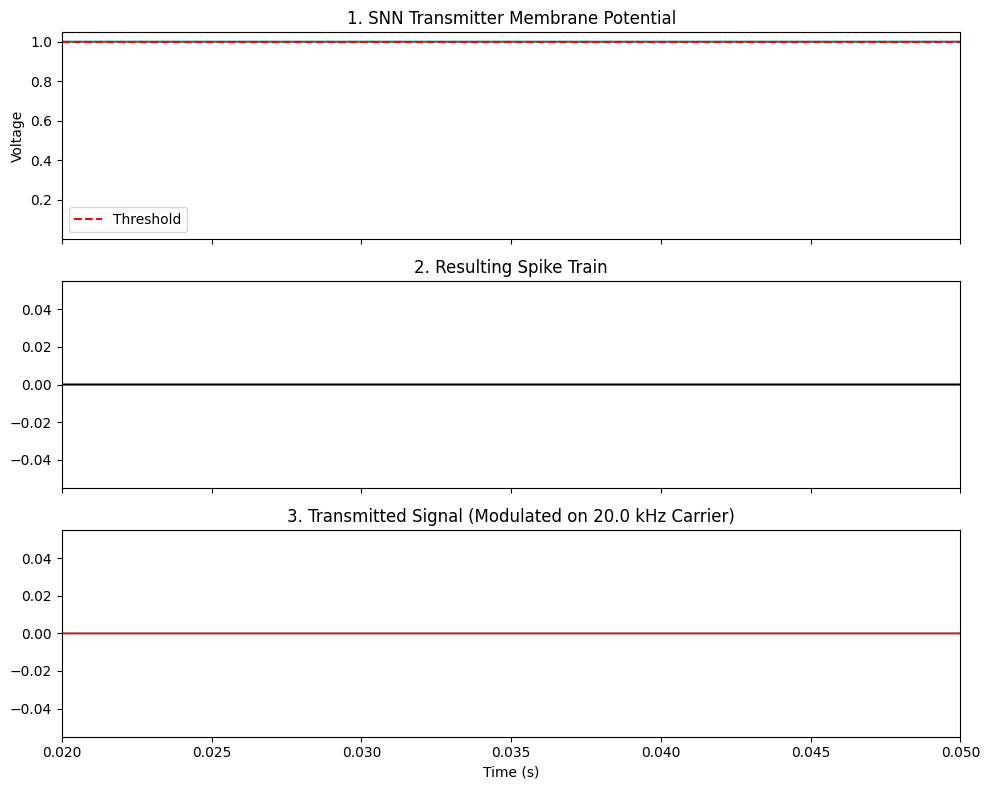

In [1]:
import torch
import snntorch as snn
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- Parameters ---
fs = 100000       # Sampling Rate (Hz)
T = 0.1           # Duration of simulation (seconds)
t_np = np.linspace(0, T, int(fs*T))
time_steps = len(t_np)

# --- 1. NEW: SNN Transmitter Setup ---
beta = 0.95            # Neuron leak (high beta = long memory/slow leak)
threshold = 1.0
input_current = torch.tensor(0.05) # Constant drive current

# Initialize the transmitter neuron
lif_transmitter = snn.Leaky(beta=beta, threshold=threshold)
mem = lif_transmitter.init_leaky()

# Simulation loop to generate spikes
mem_rec = []
spk_list = []
print("Running SNN Transmitter simulation...")
for step in range(time_steps):
    spk, mem = lif_transmitter(input_current, mem)
    
    # Store results
    mem_rec.append(mem.item())
    spk_list.append(spk)

sent_spikes_torch = torch.stack(spk_list).squeeze()
raw_spikes_np = sent_spikes_torch.detach().numpy() # Convert to numpy for scipy
print(f"SNN neuron fired {raw_spikes_np.sum()} times.")

# --- 2. Radar Chirp Params (Same as before) ---
chirp_duration = 0.005 # 5ms chirp
bw = 5000              # Bandwidth of chirp (5 kHz)
f_start = 1000         # Start Freq (1 kHz)
t_chirp_np = np.linspace(0, chirp_duration, int(fs*chirp_duration))
chirp_template_np = signal.chirp(t_chirp_np, f0=f_start, f1=f_start+bw, t1=chirp_duration, method='linear')

# Carrier Params
f_carrier = 20000      # 20 kHz Carrier
carrier_np = np.cos(2 * np.pi * f_carrier * t_np)

# --- 3. The Sifting Theorem (Convolution) ---
baseband_signal_np = signal.convolve(raw_spikes_np, chirp_template_np, mode='same')

# --- 4. Modulation (Put on Carrier) ---
tx_signal_np = baseband_signal_np * carrier_np

# --- Plotting ---
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(t_np, mem_rec, color='teal')
ax[0].axhline(threshold, color='r', linestyle='--', label="Threshold")
ax[0].set_title("1. SNN Transmitter Membrane Potential")
ax[0].set_ylabel("Voltage")
ax[0].legend()
ax[0].set_xlim(0.02, 0.05) # Zoom in

ax[1].plot(t_np, raw_spikes_np, color='black')
ax[1].set_title("2. Resulting Spike Train")

ax[2].plot(t_np, tx_signal_np, color='darkred', alpha=0.8)
ax[2].set_title(f"3. Transmitted Signal (Modulated on {f_carrier/1000} kHz Carrier)")
ax[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

### Cell 2: The 1D Channel & Receiver

This cell is the standard 1D physics model. It takes the tx_signal_np from Cell 1, simulates a round trip to a wall, and runs the receiver's matched filter. This is unchanged.

Target Distance: 5.0m | Time of Flight: 29.15 ms


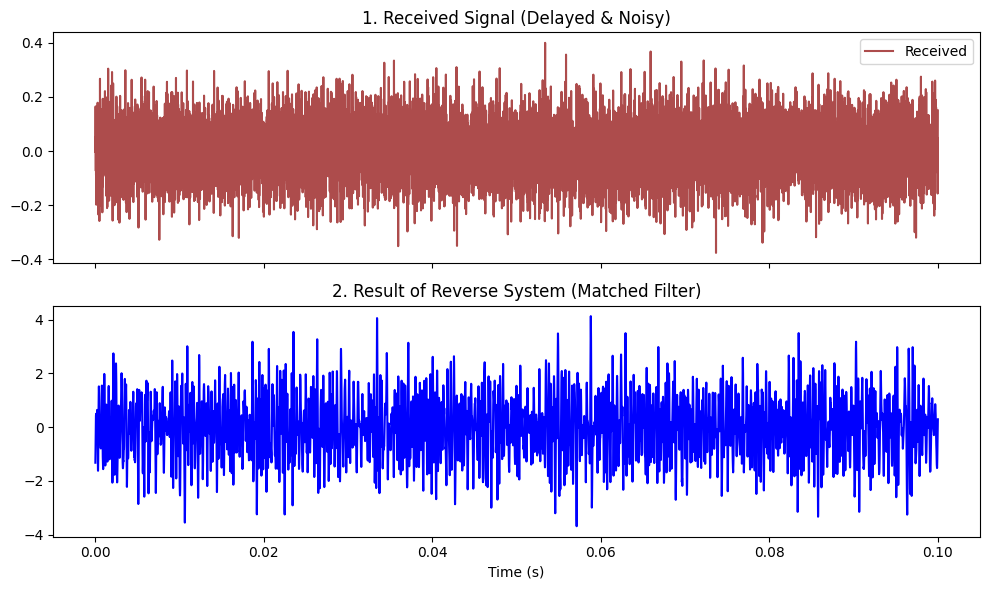

In [4]:
# --- 1. Environment & Physics Setup ---
c = 343  # Speed of sound (m/s)
wall_distance = 5.0 # Meters (Change this to move the wall!)

# --- 2. The Physics (Transmission Channel) ---
time_of_flight = (2 * wall_distance) / c
delay_samples = int(time_of_flight * fs)
print(f"Target Distance: {wall_distance}m | Time of Flight: {time_of_flight*1000:.2f} ms")

rx_signal = np.roll(tx_signal_np, delay_samples)
rx_signal = rx_signal * 0.5 
noise = np.random.normal(0, 0.1, len(rx_signal))
rx_signal = rx_signal + noise

# --- 3. The Receiver (Demodulation) ---
demod_raw = rx_signal * carrier_np
sos = signal.butter(10, f_carrier, 'low', fs=fs, output='sos')
rx_baseband = signal.sosfilt(sos, demod_raw)

# --- 4. The "Reverse System" (Matched Filter) ---
matched_filter = chirp_template_np[::-1] # Time-reversed chirp
recovered_signal = signal.convolve(rx_baseband, matched_filter, mode='same')

# --- Plotting ---
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(t_np, rx_signal, color='darkred', alpha=0.7, label="Received")
ax[0].set_title("1. Received Signal (Delayed & Noisy)")
ax[0].legend(loc="upper right")

ax[1].plot(t_np, recovered_signal, color='blue')
ax[1].set_title("2. Result of Reverse System (Matched Filter)")
ax[1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

### Cell 3: The Analysis (Classical Correlator)

This cell verifies that our system works. It correlates the recovered_signal from Cell 2 against the raw_spikes_np generated by the SNN in Cell 1. We use the constrained search (lags >= 0) to ensure a physical result.

--- RESULTS ---
Actual Wall Distance:    5.0 m
Calculated Distance:     0.0000 m
Error:                   5.0000 m


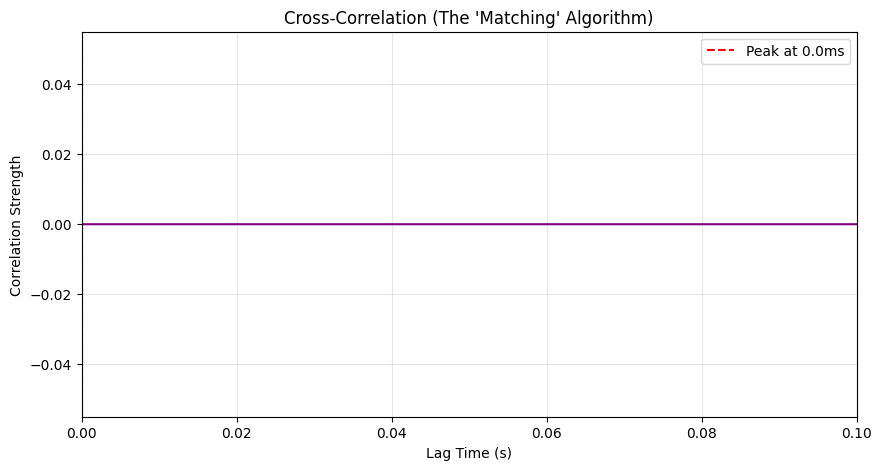

In [5]:
# --- 1. Cross-Correlation ---
correlation = signal.correlate(recovered_signal, raw_spikes_np, mode='full')
lags = signal.correlation_lags(len(recovered_signal), len(raw_spikes_np), mode='full')

# --- 2. Find the Peak (Constrained Search) ---
positive_lags_mask = (lags >= 0)
valid_lags = lags[positive_lags_mask]
valid_corr = correlation[positive_lags_mask]

peak_idx = np.argmax(valid_corr)
peak_lag = valid_lags[peak_idx]
detected_delay_time = peak_lag / fs

# --- 3. Calculate Distance ---
calculated_distance = (c * detected_delay_time) / 2

print(f"--- RESULTS ---")
print(f"Actual Wall Distance:    {wall_distance} m")
print(f"Calculated Distance:     {calculated_distance:.4f} m")
print(f"Error:                   {abs(wall_distance - calculated_distance):.4f} m")

# --- Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

lag_time = lags / fs
ax.plot(lag_time, correlation, color='purple')
ax.axvline(detected_delay_time, color='red', linestyle='--', label=f"Peak at {detected_delay_time*1000:.1f}ms")
ax.set_title("Cross-Correlation (The 'Matching' Algorithm)")
ax.set_xlabel("Lag Time (s)")
ax.set_ylabel("Correlation Strength")
ax.legend()
ax.set_xlim(0, T) # Only look at positive time delays
plt.grid(True, alpha=0.3)
plt.show()